In [17]:
%load_ext autoreload
%autoreload 2

import numpy as np
import time
import h5py
import pickle
import matplotlib.pyplot as plt
from scipy.stats import norm
from concurrent.futures import ProcessPoolExecutor, as_completed

from Closed_form import *
from FDM import *
from MC import *
# import os

# global var
S0 = 1.0
K = 1.0
r = 0.03
sigma = np.sqrt(0.05)
T = 1.5
BS_eta = (S0, K, r, sigma, T)
# S0, K, r, kappa, theta, xi, rho, Y0, T = Hes_eta
Hes_eta = (S0, K, r, 2, 0.05, 0.5, -0.7, 0.05, T)

# down-and-out must B < S0
B = 0.8 
if not(B < S0):
    raise ValueError("down-and-out : B should be smaller than S0")

# type : call or put
opt_type = 'put' 
if not(opt_type == 'call' or  opt_type == 'put'):
    raise ValueError("option_type must be 'call' or 'put'")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# 1. closed-form pricing result
closed_bs_van = BS_vanilla(BS_eta, opt_type)
closed_bs_barr = BS_barrier(BS_eta, B, opt_type)

In [11]:
# 2. MC
mc_bs_van_gpu = MC_BS_vanilla_gpu(BS_eta, n_paths=100000, type=opt_type)
mc_hes_van_gpu = MC_heston_vanilla_gpu(Hes_eta, n_paths=100000, type=opt_type)
# BS_van
# CPU vanilla(1k, 10k, 100k) = (0.042, 0.453, 4.783)
# GPU vanilla(1k, 10k, 100k) = (0.143, 0.156, 0.163)

# Hes_van
# CPU vanilla(1k, 10k, 100k) = (0.112, 1.160, 11.992)
# GPU vanilla(1k, 10k, 100k) = (0.438, 0.485, 0.54)

#start = time.time()
mc_bs_barr_gpu = MC_BS_barrier_gpu(BS_eta, B, n_paths=100000, type=opt_type)
mc_hes_barr_gpu = MC_heston_barrier_gpu(Hes_eta, B, n_paths=100000, type=opt_type)
#print(f"{time.time() - start:.3f}s")
# BS_barr
# CPU vanilla(1k, 10k, 100k) = ( , , )
# GPU vanilla(1k, 10k, 100k) = ( 0.150, 0.150, 0.155)

# Hes_barr
# CPU vanilla(1k, 10k, 100k) = ( , , )
# GPU vanilla(1k, 10k, 100k) = ( 0.45, 0.47, 0.53)

In [15]:
# 3. FDM
# heston - call / put : dS=0.01, dv=0.0001, dt=0.01
ftcs_bs_van = FTCS_BS_vanilla(BS_eta, opt_type)
cn_bs_van = CN_BS_vanilla(BS_eta, opt_type)
#cs_hes_van = CS_ADI_heston_vanilla(Hes_eta, opt_type)


# heston - call / put : dS=0.01, dv=0.0001, dt=0.01
ftcs_bs_barr = FTCS_BS_barrier(BS_eta, opt_type, B)
cn_bs_barr = CN_BS_barrier(BS_eta, opt_type, B)
#cs_hes_barr = CS_ADI_heston_barrier(Hes_eta, opt_type)

In [18]:
cs_hes_van = CS_ADI_heston_vanilla(Hes_eta, opt_type, dS=0.01, dv=0.0001, dt=0.01) # put인경우
cs_hes_barr = CS_ADI_heston_barrier(Hes_eta, opt_type, B, dS=0.01, dv=0.0001, dt=0.01) # put인경우

In [ ]:
#start = time.time()
#print(f"{time.time() - start:.3f}s")

In [12]:
# Total result
#vanilla
print(closed_bs_van, mc_bs_van_gpu, ftcs_bs_van, cn_bs_van)
print(f"{(mc_bs_van_gpu - closed_bs_van) / closed_bs_van * 100}%")
print(f"{(ftcs_bs_van - closed_bs_van) / closed_bs_van * 100}%")
print(f"{(cn_bs_van - closed_bs_van) / closed_bs_van * 100}%\n")

print(mc_hes_van_gpu, cs_hes_van)
print(f"{(cs_hes_van - mc_hes_van_gpu) / mc_hes_van_gpu * 100}%\n\n")

#barrier
print(closed_bs_barr, mc_bs_barr_gpu, ftcs_bs_barr, cn_bs_barr)
print(f"{(mc_bs_barr_gpu - closed_bs_barr) / closed_bs_barr * 100}%")
print(f"{(ftcs_bs_barr - closed_bs_barr) / closed_bs_barr * 100}%")
print(f"{(cn_bs_barr - closed_bs_barr) / closed_bs_barr * 100}%\n")

print(mc_hes_barr_gpu, cs_hes_barr)
print(f"{(cs_hes_barr - mc_hes_barr_gpu) / mc_hes_barr_gpu * 100}%")


0.08594238962559853 0.08579112088846073 0.08592574698698162 0.08592499052134153
-0.17601178859091776%
-0.01936487766910952%
-0.020245078514561993%

0.08076575146416928 0.08048871140971021
-0.3430167483577167%


0.009535211077589895 0.009542340950160547 0.009518704566123184 0.00951805983134698
0.07477414514094675%
-0.1731111281375286%
-0.17987274852493398%

0.005171241447398277 0.00517055896008722
-0.013197745995798362%


In [ ]:
n_list    = [1000, 10000, 100000]
n_repeats = 50
results   = {n: [] for n in n_list}

for n in n_list:
    for _ in range(n_repeats):
        price = MC_heston_vanilla_gpu(Hes_eta, n_paths=n, type=opt_type) # MC_heston_barrier_gpu
        results[n].append(price)

# pickle은 binary로.
with open('mc_hes_van_put_results.pkl', 'wb') as f:
    pickle.dump(results, f)

In [ ]:
'''
configs = [ # vanilla
    # call
    dict(dS=0.01, dv=0.01, dt=0.01),  # present = dict(dS=0.01, dv=0.01, dt=0.005), dict(dS=0.01, dv=0.01, dt=0.001), = 0.129976
    dict(dS=0.005, dv=0.005, dt=0.005), # = 0.127356
    dict(dS=0.002, dv=0.002, dt=0.005), # = 0.125731, dt=0.01에서 줄여도 큰 차이 없음
    dict(dS=0.002, dv=0.002, dt=0.01), # = 0.125723
    dict(dS=0.002, dv=0.001, dt=0.01), # = 0.125134
    dict(dS=0.001, dv=0.002, dt=0.01), # = 0.125692, 메모리 10% 사용, dv 줄이는게 영향이 더 큼
    dict(dS=0.001, dv=0.001, dt=0.01), # = 0.125106
    dict(dS=0.01, dv=0.001, dt=0.01), # = 0.125122, 22s ***
    dict(dS=0.01, dv=0.0001, dt=0.01), # = 0.124491, 3m 44s *****
    dict(dS=0.001, dv=0.0001, dt=0.01), # = 0.124478, 28m, 38% 사용
    dict(dS=0.01, dv=0.00001, dt=0.01), # = 0.124395, 40m 41s
    dict(dS=0.0005, dv=0.0005, dt=0.01), # = 0.124748, 1step 5초
    dict(dS=0.0001, dv=0.0005, dt=0.01), # memory error
    dict(dS=0.0001, dv=0.0001, dt=0.01), # memory error
    #put
    dict(dS=0.01, dv=0.01, dt=0.01), # = 0.085973
    dict(dS=0.01, dv=0.001, dt=0.01), # = 0.081119
    dict(dS=0.01, dv=0.0001, dt=0.01), # = 0.080489 *****
]

configs = [ # heston
    # call
    #dict(dS=0.01, dv=0.001, dt=0.01), # = 0.116258, 20.3s
    #dict(dS=0.01, dv=0.0001, dt=0.01), # = 0.115734, 3m 37s ***
    #dict(dS=0.001, dv=0.0001, dt=0.01), # = 0.115722, 21m 20s
    #dict(dS=0.01, dv=0.00001, dt=0.01), # = 0.115654, 44m 26s
    # put
    #dict(dS=0.01, dv=0.01, dt=0.01), # = 0.005394, 3.6s, 
    #dict(dS=0.01, dv=0.001, dt=0.01), # = 0.005213, 20.6s, 
    #dict(dS=0.01, dv=0.0001, dt=0.01), # = 0.005171, 3m 22s,
    #dict(dS=0.001, dv=0.01, dt=0.01), # = 0.005410,  
    #dict(dS=0.0001, dv=0.01, dt=0.01), # = 0.005410
    #dict(dS=0.001, dv=0.001, dt=0.01), # =0.005231
]
'''

for cfg in configs:
    p = CS_ADI_heston_vanilla(Hes_eta, type=opt_type, **cfg)
    print(cfg, f"→ {p:.6f}")

0/150
1/150
2/150
3/150
4/150
5/150
6/150
7/150
8/150
9/150
10/150
11/150
12/150
13/150
14/150
15/150
16/150
17/150
18/150
19/150
20/150
21/150
22/150
23/150
24/150
25/150
26/150
27/150
28/150
29/150
30/150
31/150
32/150
33/150
34/150
35/150
36/150
37/150
38/150
39/150
40/150
41/150
42/150
43/150
44/150
45/150
46/150
47/150
48/150
49/150
50/150
51/150
52/150
53/150
54/150
55/150
56/150
57/150
58/150
59/150
60/150
61/150
62/150
63/150
64/150
65/150
66/150
67/150
68/150
69/150
70/150
71/150
72/150
73/150
74/150
75/150
76/150
77/150
78/150
79/150
80/150
81/150
82/150
83/150
84/150
85/150
86/150
87/150
88/150
89/150
90/150
91/150
92/150
93/150
94/150
95/150
96/150
97/150
98/150
99/150
100/150
101/150
102/150
103/150
104/150
105/150
106/150
107/150
108/150
109/150
110/150
111/150
112/150
113/150
114/150
115/150
116/150
117/150
118/150
119/150
120/150
121/150
122/150
123/150
124/150
125/150
126/150
127/150
128/150
129/150
130/150
131/150
132/150
133/150
134/150
135/150
136/150
137/150
138/15

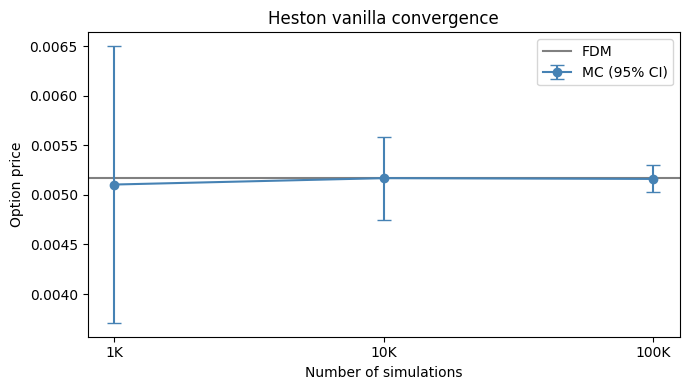

In [ ]:
fdm_price = 0.005171
n_list    = [1000, 10000, 100000]
with open('mc_hes_barr_put_corr_results.pkl', 'rb') as f:
    results = pickle.load(f)
    
means  = [np.mean(results[n]) for n in n_list]
stds   = [np.std(results[n])  for n in n_list]
ci     = [1.96 * s for s in stds]

plt.figure(figsize=(7, 4))
plt.axhline(fdm_price, color='gray', linewidth=1.5, label='FDM')
plt.errorbar(range(len(n_list)), means, yerr=ci,
             fmt='o-', color='steelblue', capsize=5, label='MC (95% CI)')
plt.xticks(range(len(n_list)), ['1K', '10K', '100K'])
plt.xlabel('Number of simulations')
plt.ylabel('Option price')
plt.title('convergence')
plt.legend()
plt.tight_layout()